# Notebook 10 - Framework Summary (Copenhagen)

Thin wrapper around `cityheat.nb10_summary.run_nb10_summary`.
It reads saved outputs from NB01-NB09 and writes summary figures to `outputs/copenhagen/figures/summary/`.

In [1]:
from pathlib import Path
import sys

def _find_root() -> Path:
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CITY_SLUG = "copenhagen"
ROOT

PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat')

In [2]:
from cityheat.nb10_summary import run_nb10_summary

results = run_nb10_summary(CITY_SLUG, verbose=True)
results

NB10 Summary Dashboard — Copenhagen (copenhagen)
Using outputs in /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen
[1_city_profile] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_01_city_profile_copenhagen.png
[2_climate_hazard] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_02_climate_hazard_copenhagen.png
[3_vulnerability] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_03_vulnerability_copenhagen.png
[4_mortality_if] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_04_mortality_if_copenhagen.png
[5_policy_levers] saved -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_05_policy_levers_copenhagen.png
[6_cba_dashboard] saved -> /Users/armande

{'1_city_profile': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_01_city_profile_copenhagen.png')],
 '2_climate_hazard': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_02_climate_hazard_copenhagen.png')],
 '3_vulnerability': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_03_vulnerability_copenhagen.png')],
 '4_mortality_if': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_04_mortality_if_copenhagen.png')],
 '5_policy_levers': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_05_policy_levers_copenhagen.png')],
 '6_cba_dashboard': [PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_06_cba

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_01_city_profile_copenhagen.png


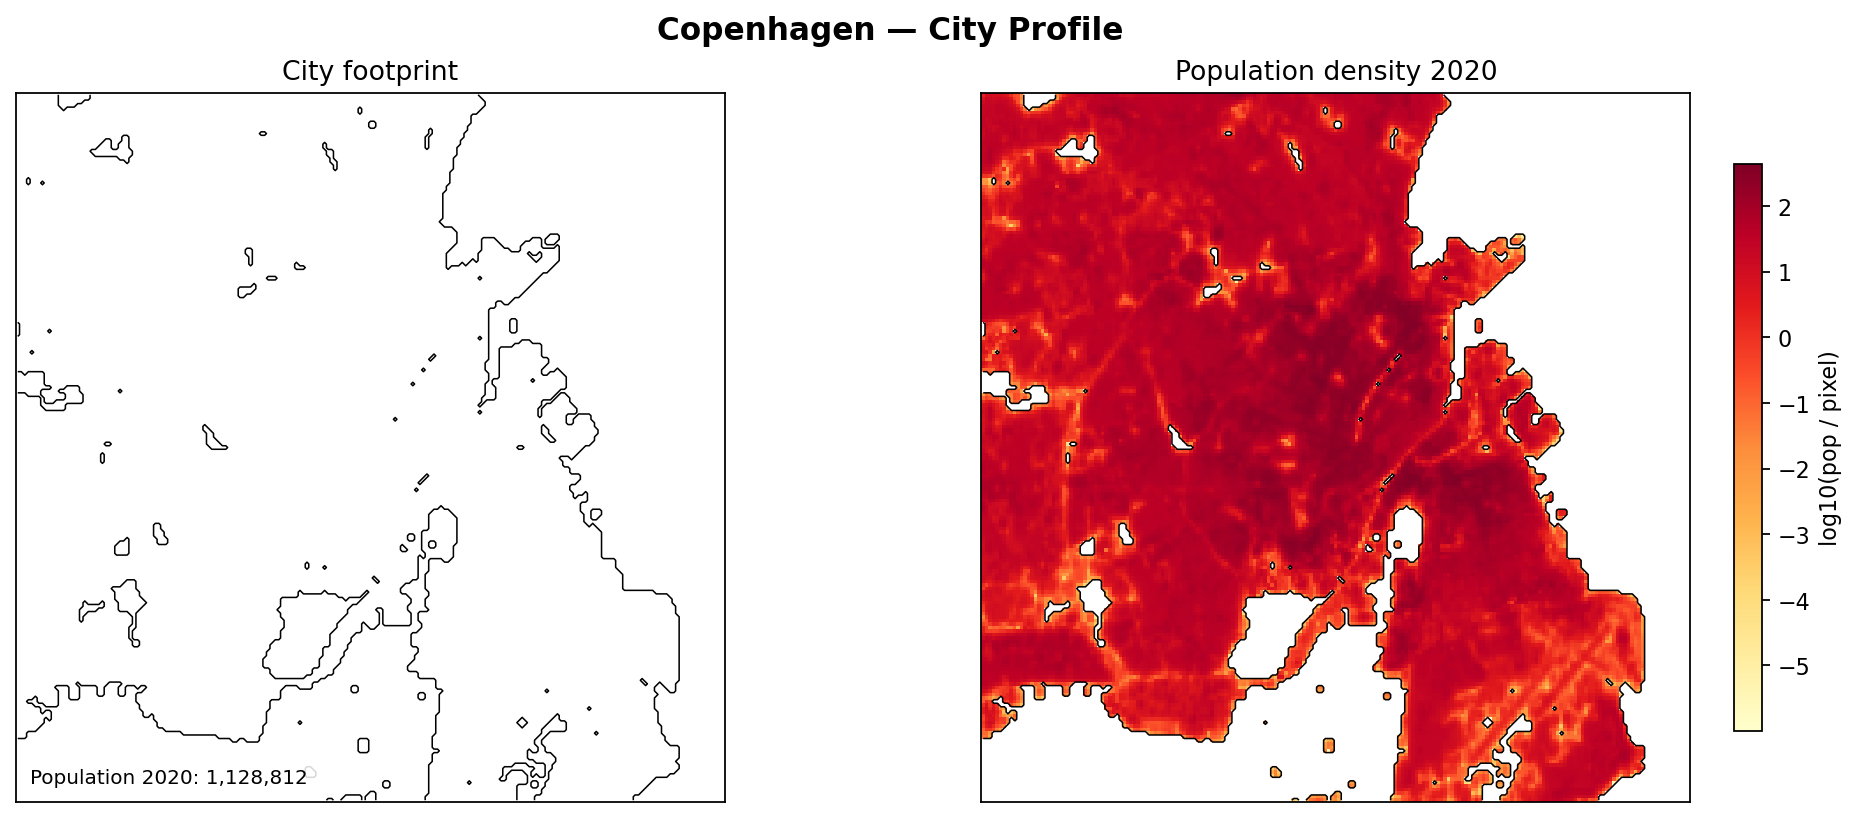

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_02_climate_hazard_copenhagen.png


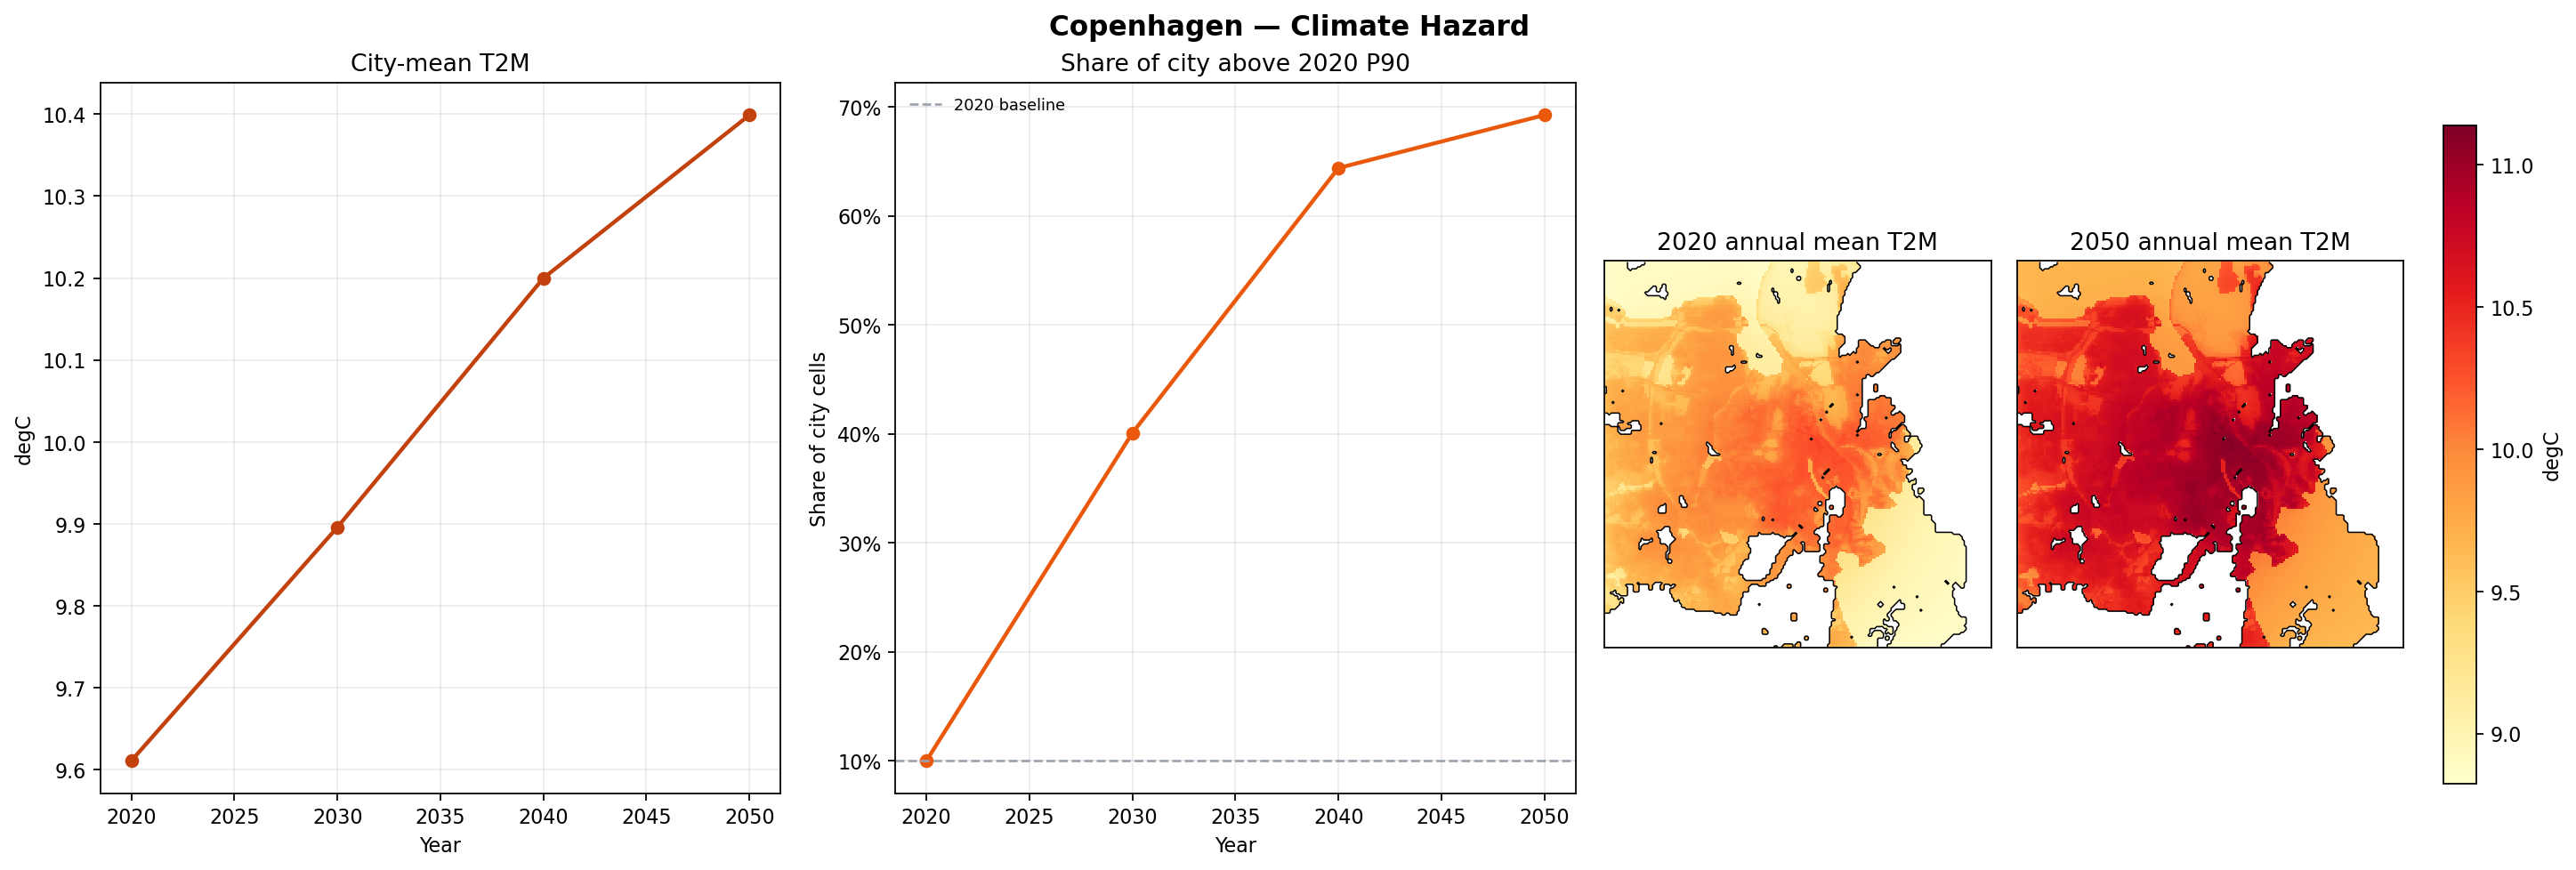

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_03_vulnerability_copenhagen.png


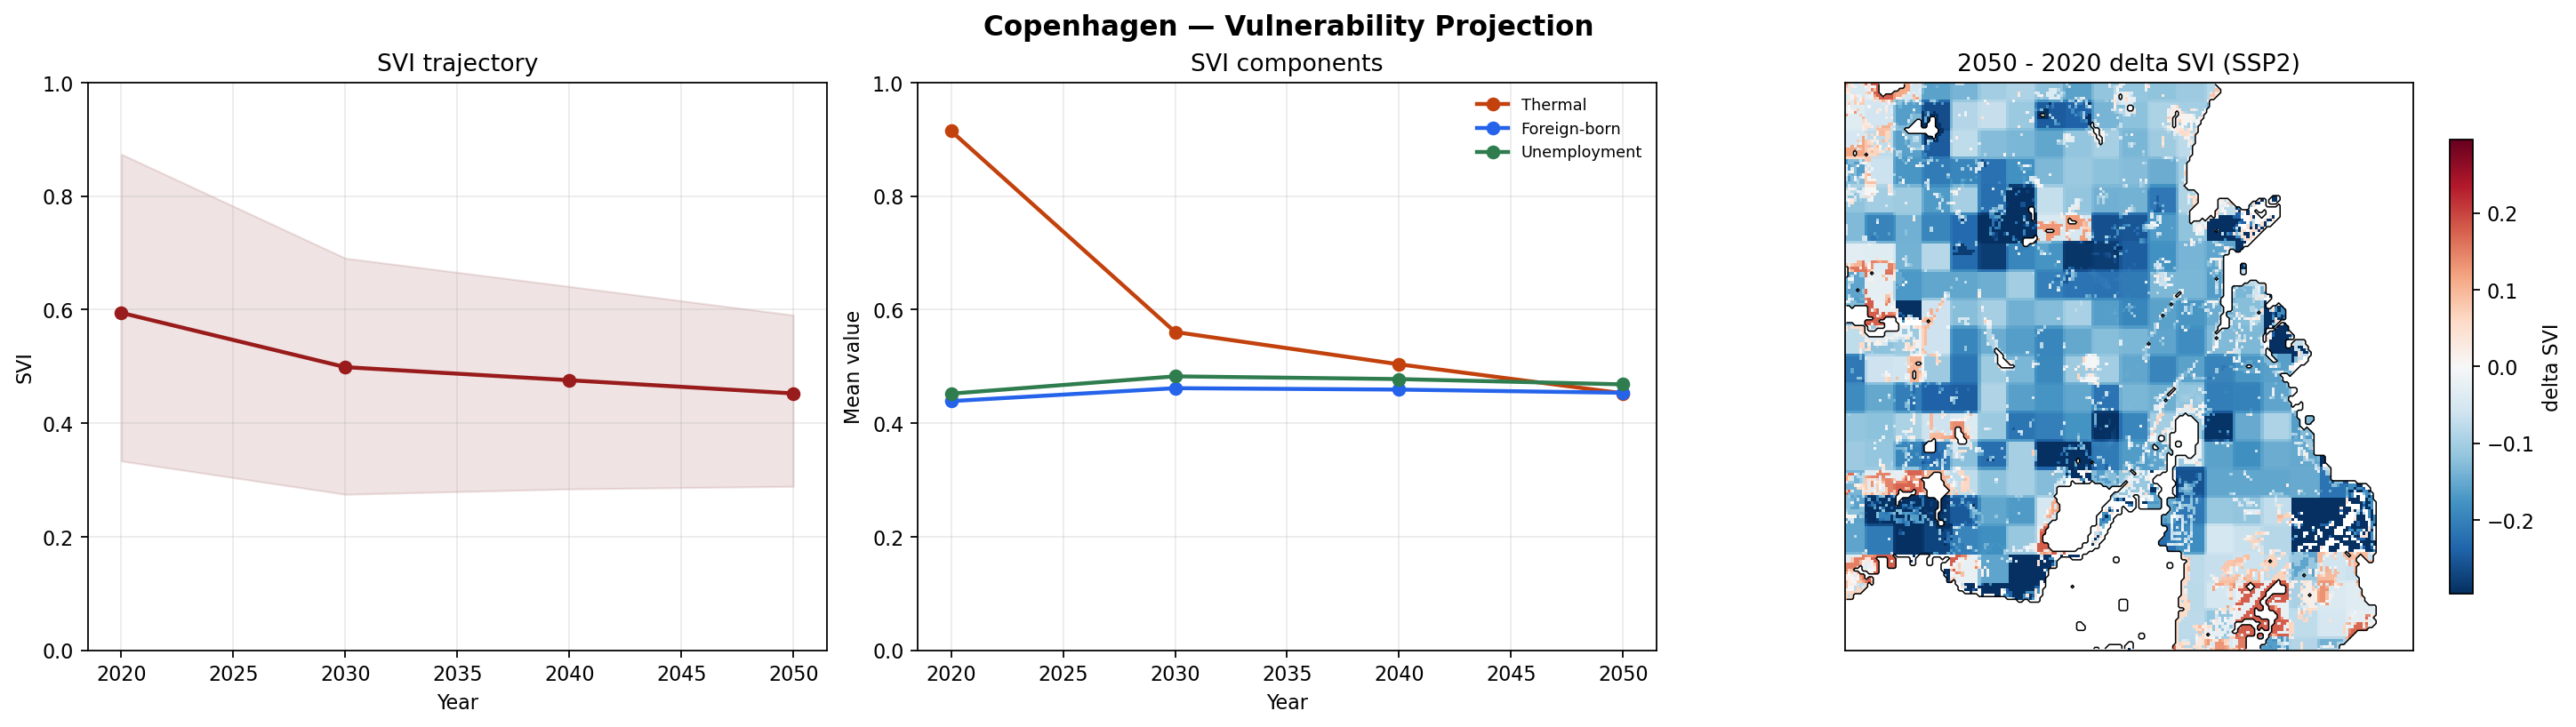

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_04_mortality_if_copenhagen.png


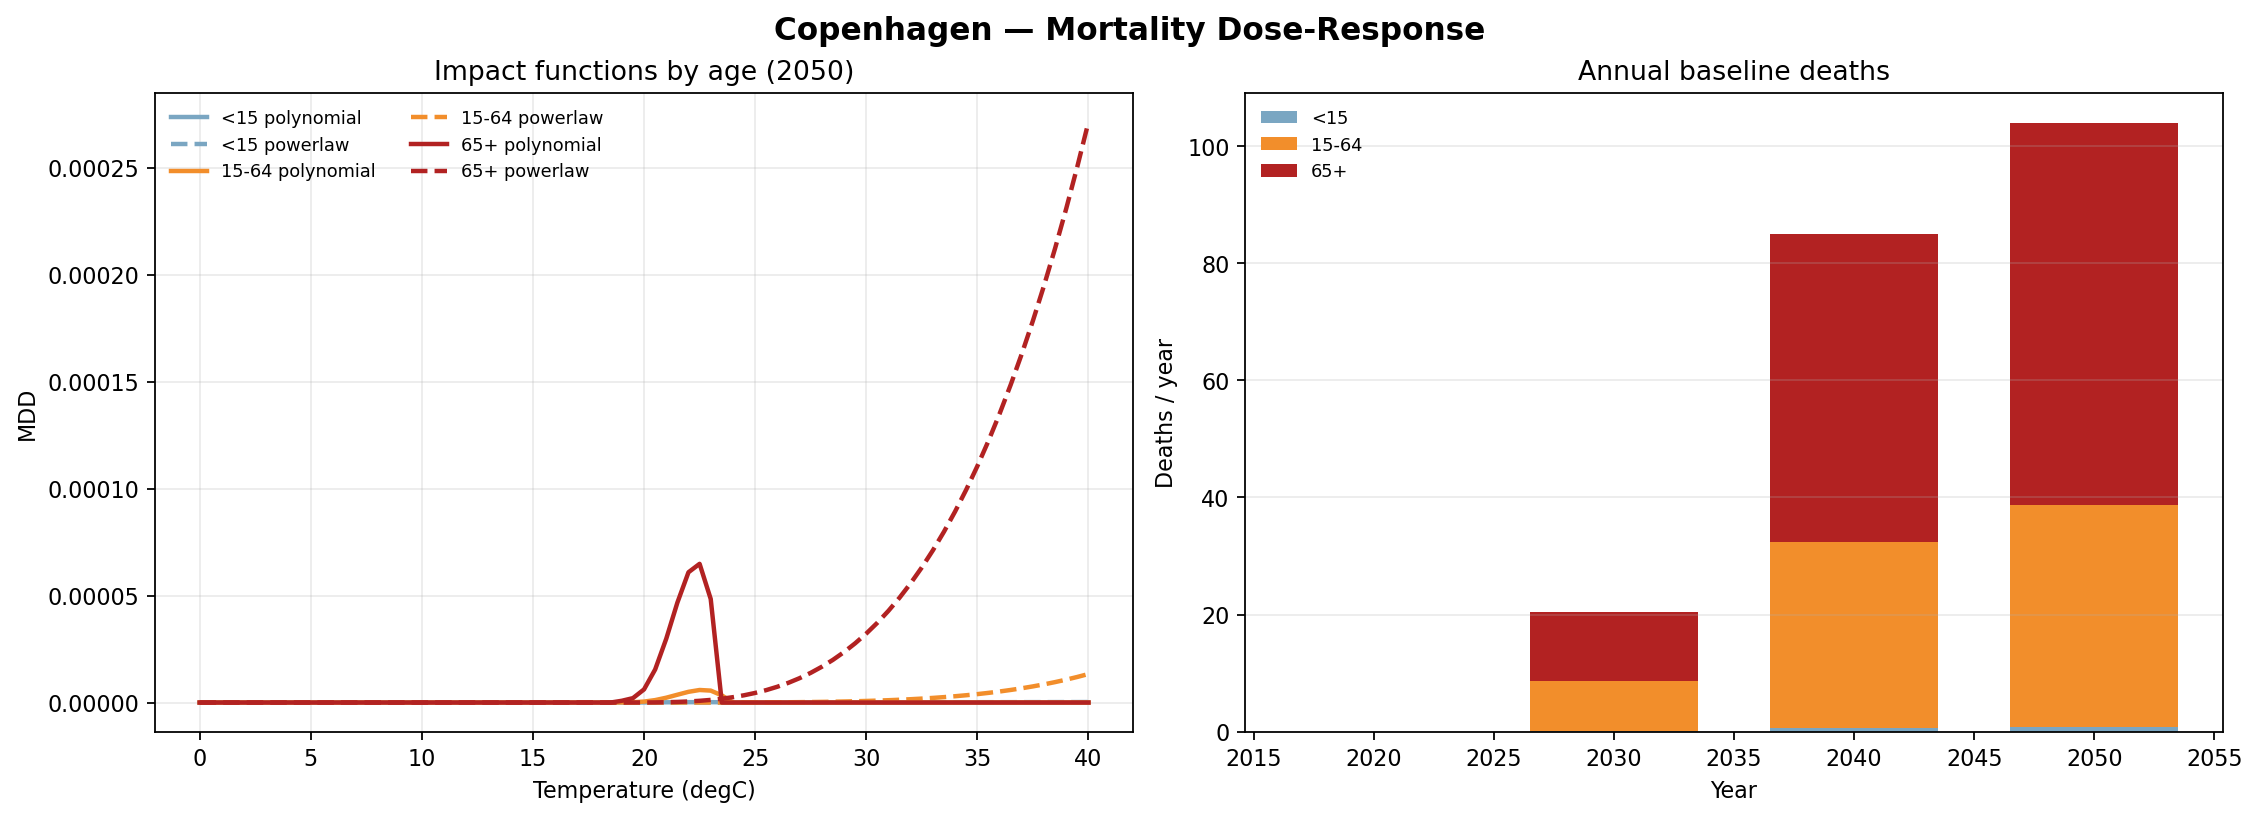

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_05_policy_levers_copenhagen.png


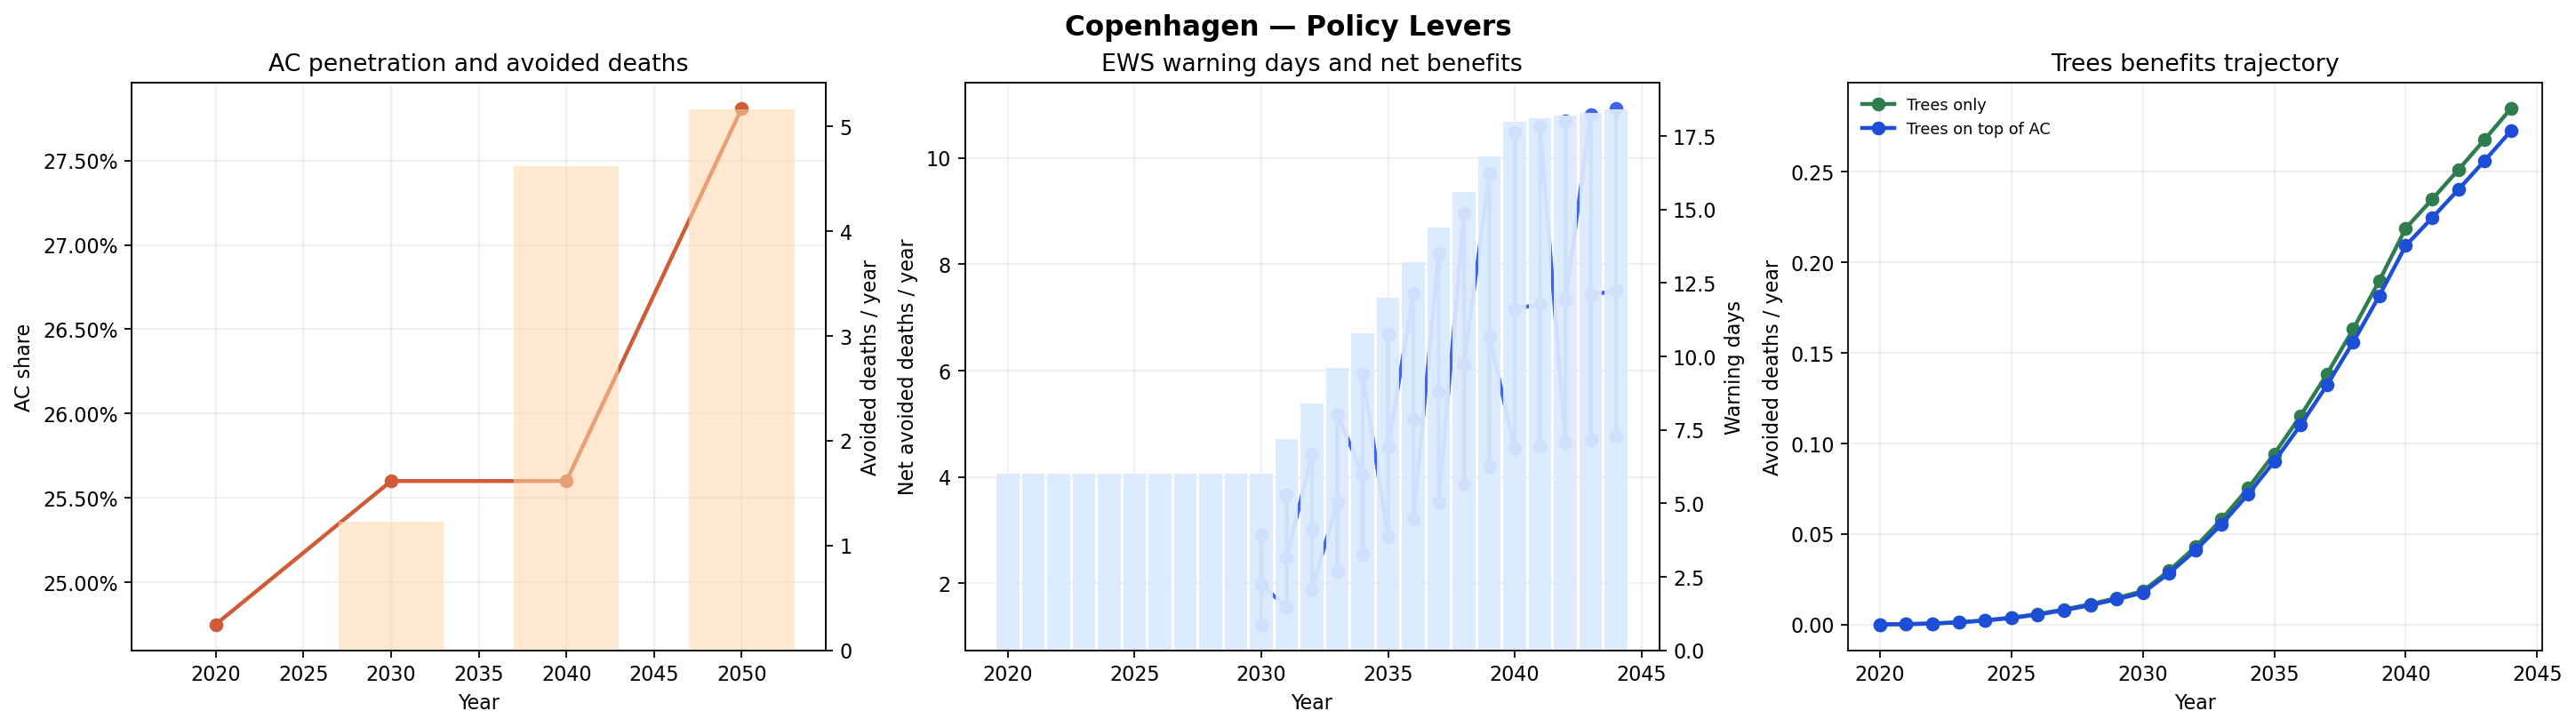

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_06_cba_dashboard_copenhagen.png


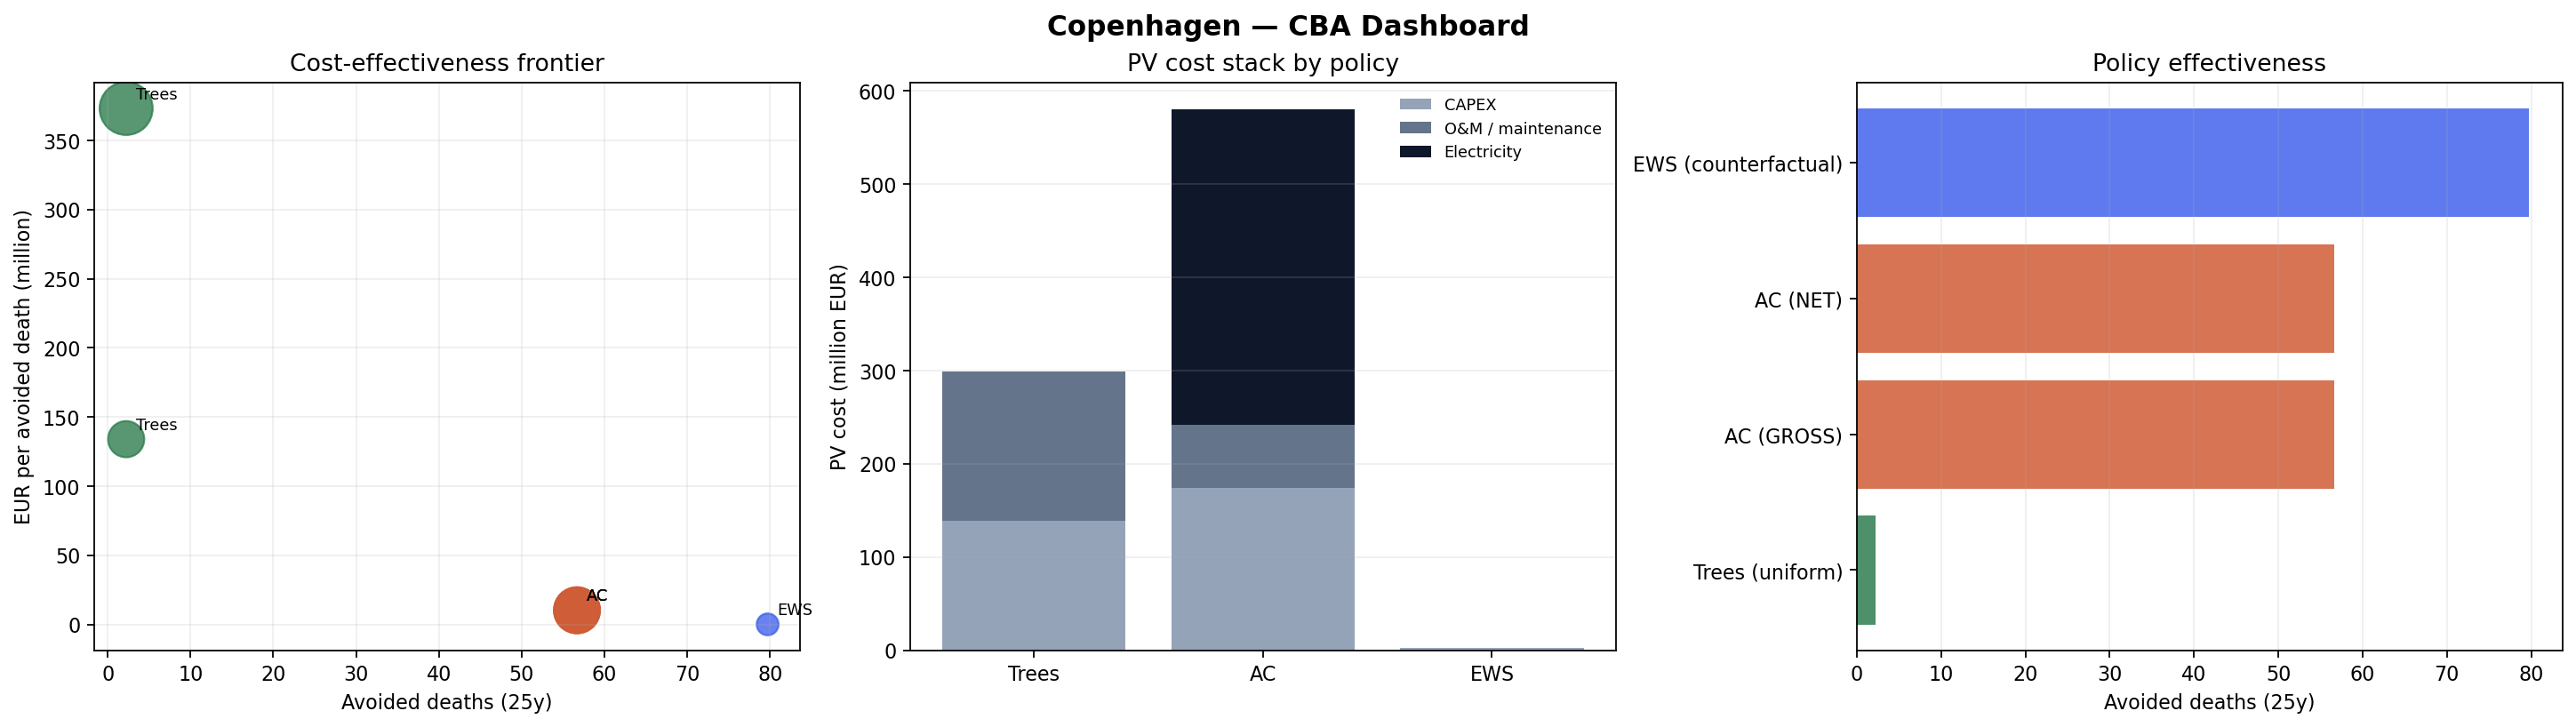

/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/figures/summary/summary_07_uncertainty_copenhagen.png


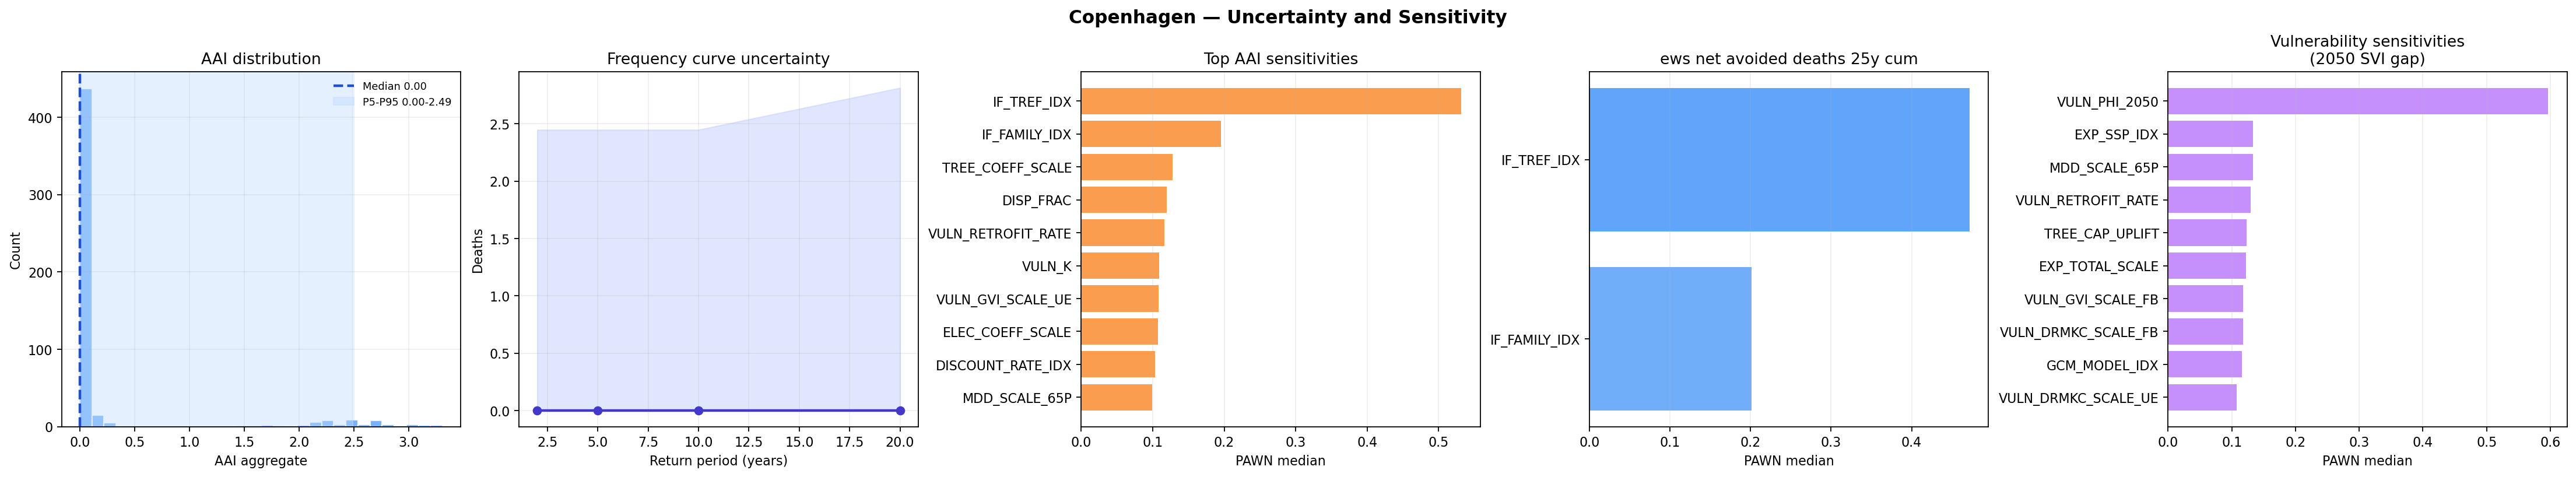

In [3]:
from IPython.display import Image, display

figure_paths = [
    path
    for key, paths in results.items()
    if key != "summary_metrics"
    for path in paths
]

for path in figure_paths:
    print(path)
    display(Image(filename=str(path)))

In [4]:
import pandas as pd

metrics_path = ROOT / "outputs" / CITY_SLUG / "tables" / f"{CITY_SLUG}_framework_summary_metrics.csv"
metrics = pd.read_csv(metrics_path)
metrics

,section,metric,value,unit
0,city_profile,population_2020,1128812,people
1,hazard,citymean_degC_2020,9.61,degC
2,hazard,citymean_degC_2050,10.4,degC
3,hazard,delta_citymean_degC_2050_2020,0.79,degC
4,vulnerability,svi_mean_2020,0.594,NaN
5,vulnerability,svi_mean_2050,0.452,NaN
6,mortality,baseline_deaths_2020,0.0,deaths/yr
7,mortality,baseline_deaths_2050,103.9,deaths/yr
8,policy,avoided_deaths_25y_trees_uniform,2.2,deaths
9,policy,avoided_deaths_25y_ac_gross,56.7,deaths


In [5]:
# Explicit standard-vs-extreme side-by-side synthesis for Copenhagen.
import numpy as np
import pandas as pd

int_dir = ROOT / "outputs" / CITY_SLUG / "interim"
std_y = int_dir / f"hazard_events_T2M_yearly_{CITY_SLUG}.csv"
ext_y = int_dir / f"hazard_events_T2M_yearly_{CITY_SLUG}_extreme.csv"

if not std_y.exists() or not ext_y.exists():
    raise FileNotFoundError(
        "Need both standard and extreme yearly hazard summaries. "
        f"Missing: {[str(p) for p in [std_y, ext_y] if not p.exists()]}"
    )

std = pd.read_csv(std_y).rename(columns={"citymean_degC": "trackA_citymean_degC"})
ext = pd.read_csv(ext_y).rename(columns={
    "n_event_days": "trackB_event_days",
    "mean_event_intensity_citymean_degC": "trackB_mean_event_exceedance_degC",
    "max_event_intensity_citymean_degC": "trackB_max_event_exceedance_degC",
})

side = std.merge(ext[["year", "trackB_event_days", "trackB_mean_event_exceedance_degC", "trackB_max_event_exceedance_degC"]], on="year", how="left")
side["trackB_event_days"] = side["trackB_event_days"].fillna(0).astype(int)
for c in ["trackB_mean_event_exceedance_degC", "trackB_max_event_exceedance_degC"]:
    side[c] = side[c].fillna(0.0)

side["trackA_has_policy_signal"] = np.where(side["trackA_citymean_degC"] > 0, "baseline-only (cold-city)", "baseline-only")

out_csv = ROOT / "outputs" / CITY_SLUG / "tables" / f"{CITY_SLUG}_standard_vs_extreme_summary.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
side.to_csv(out_csv, index=False)
print(f"Saved side-by-side track summary -> {out_csv}")
side

Saved side-by-side track summary -> /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/tables/copenhagen_standard_vs_extreme_summary.csv


,year,n_days,trackA_citymean_degC,trackB_event_days,trackB_mean_event_exceedance_degC,trackB_max_event_exceedance_degC,trackA_has_policy_signal
0,2020,366,9.611029,0,0.000000,0.000000,baseline-only (cold-city)
1,2030,365,9.895939,6,0.008072,0.862222,baseline-only (cold-city)
2,2040,366,10.199961,18,0.031973,1.230571,baseline-only (cold-city)
3,2050,365,10.398931,19,0.039209,1.444501,baseline-only (cold-city)
